In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import itertools
import sqlite3


## Unoptimized Input Delta

In [3]:
forward_charact = [
    pd.read_csv("2026-05-29/output/1_round_differentials").drop("Unnamed: 0", axis=1).rename(columns=lambda c: c + '_1f' if c != 'Input_diff' else c),
    pd.read_csv("2026-05-29/output/2_round_differentials").drop("Unnamed: 0", axis=1).rename(columns=lambda c: c + '_2f' if c != 'Input_diff' else c),
    pd.read_csv("2026-05-29/output/3_round_differentials").drop("Unnamed: 0", axis=1).rename(columns=lambda c: c + '_3f' if c != 'Input_diff' else c),
    pd.read_csv("2026-05-29/output/4_round_differentials").drop("Unnamed: 0", axis=1).rename(columns=lambda c: c + '_4f' if c != 'Input_diff' else c)
    ]

backward_charact = [
    pd.read_csv("2026-05-29/output/1_round_reverse_differentials").drop("Unnamed: 0", axis=1).rename(columns=lambda c: c + '_1b' if c != 'Input_diff' else c),
    pd.read_csv("2026-05-29/output/2_round_reverse_differentials").drop("Unnamed: 0", axis=1).rename(columns=lambda c: c + '_2b' if c != 'Input_diff' else c),
    pd.read_csv("2026-05-29/output/3_round_reverse_differentials").drop("Unnamed: 0", axis=1).rename(columns=lambda c: c + '_3b' if c != 'Input_diff' else c)
    ]

sol_forward = range(0, 4+1)
sol_backward = range(0, 3+1)
candidates = forward_charact[0].copy().drop(columns=[f"Round{i}_1f" for i in range(4)])

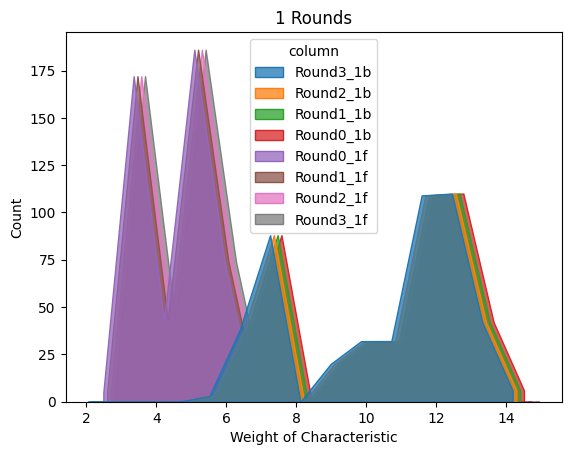

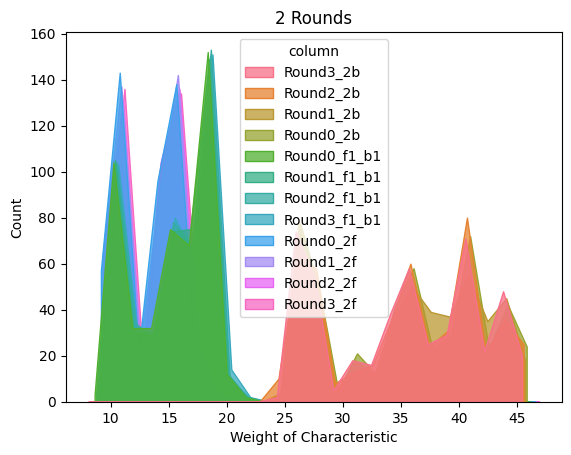

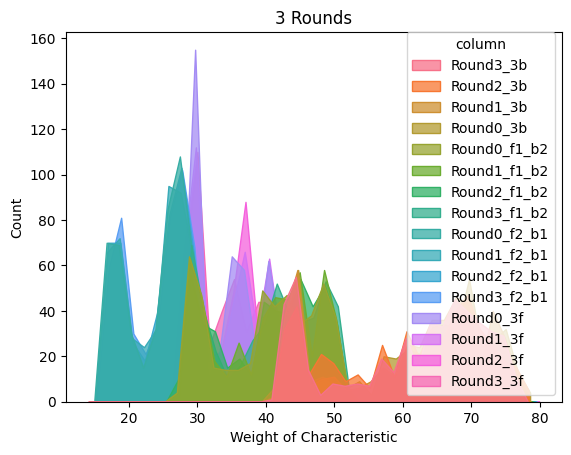

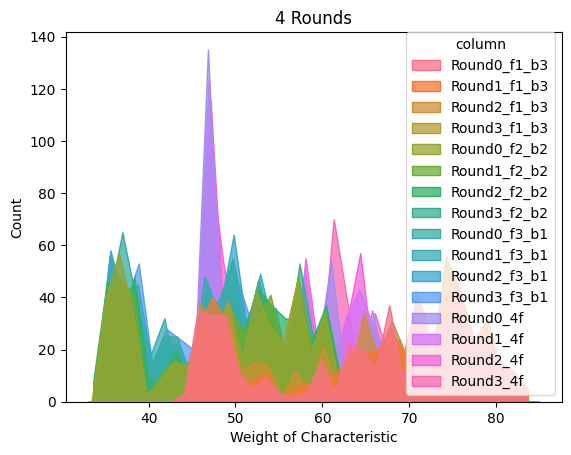

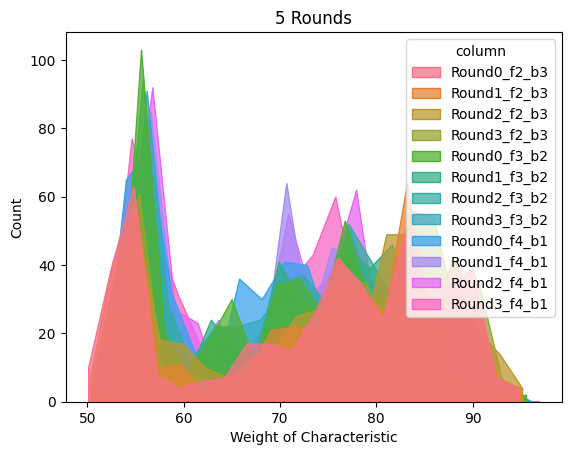

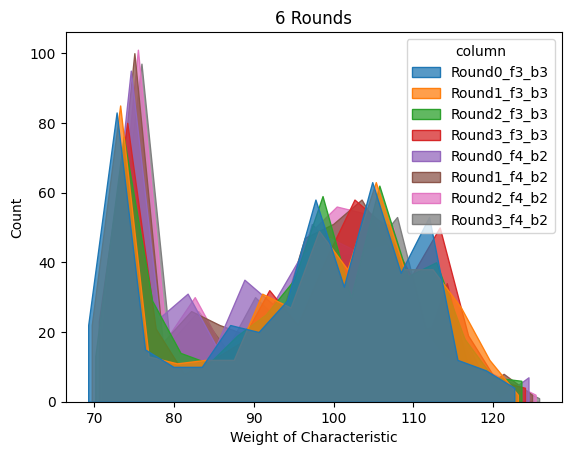

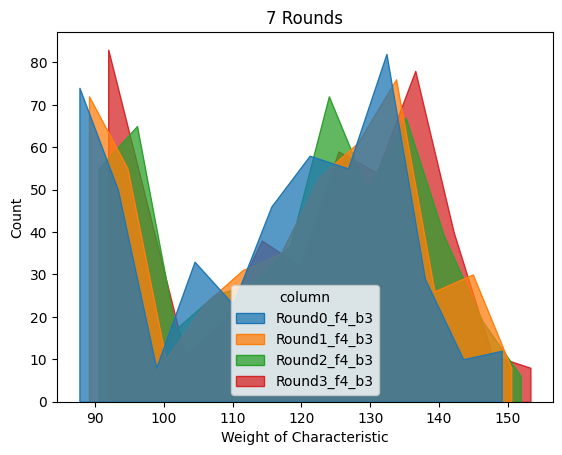

In [4]:
for rounds in range(1, max(sol_forward) + max(sol_backward) + 1):
    merged = candidates.copy()
    for (f,b) in [(a,b) for a,b in itertools.product(sol_forward,sol_backward) if a+b==rounds]:
        if f == 0:
            merged = merged.merge(backward_charact[b-1], on="Input_diff", how="inner")
        elif b == 0:
            merged = merged.merge(forward_charact[f-1], on="Input_diff", how="inner")
        else:
            merged = merged.merge(forward_charact[f-1], on="Input_diff", how="inner")
            merged = merged.merge(backward_charact[b-1], on="Input_diff", how="inner")
            for first_round in range(4):
                merged[f"Round{first_round}_f{f}_b{b}"] = merged[f"Round{first_round}_{f}f"] + merged[f"Round{first_round}_{b}b"]
                merged = merged.drop([f"Round{first_round}_{f}f", f"Round{first_round}_{b}b"], axis=1)

        
        
    ax = sns.histplot(
        merged.melt(id_vars="Input_diff", var_name='column', value_name='value'),
        x = "value",
        hue="column",
        multiple="dodge",
        element="poly"
    )

    ax.set_xlabel("Weight of Characteristic")
    ax.set_title(f"{rounds} Rounds")
    plt.show()

## Optimized for first forward round

In [27]:
forward_charact = [
    pd.read_csv("2026-05-30/output/1_round_differentials_f").drop("Unnamed: 0", axis=1).rename(columns=lambda c: c + '_1f' if c != 'input_diff' else c),
    pd.read_csv("2026-05-30/output/2_round_differentials_f").drop("Unnamed: 0", axis=1).rename(columns=lambda c: c + '_2f' if c != 'input_diff' else c),
    pd.read_csv("2026-05-30/output/3_round_differentials_f").drop("Unnamed: 0", axis=1).rename(columns=lambda c: c + '_3f' if c != 'input_diff' else c),
    pd.read_csv("2026-05-30/output/4_round_differentials_f").drop("Unnamed: 0", axis=1).rename(columns=lambda c: c + '_4f' if c != 'input_diff' else c),
    pd.read_sql_table("probabilities", "sqlite:///2026-06-02/5_round_differentials_f_p.db").drop("i", axis=1).rename(columns=lambda c: c + '_5f' if c != 'input_diff' else c),
    pd.read_sql_table("probabilities", "sqlite:///2026-06-02/6_round_differentials_f_p.db").drop("i", axis=1).rename(columns=lambda c: c + '_6f' if c != 'input_diff' else c)
    ]

backward_charact = [
    pd.read_csv("2026-05-30/output/1_round_differentials_b").drop("Unnamed: 0", axis=1).rename(columns=lambda c: c + '_1b' if c != 'input_diff' else c),
    pd.read_csv("2026-05-30/output/2_round_differentials_b").drop("Unnamed: 0", axis=1).rename(columns=lambda c: c + '_2b' if c != 'input_diff' else c),
    pd.read_csv("2026-05-30/output/3_round_differentials_b").drop("Unnamed: 0", axis=1).rename(columns=lambda c: c + '_3b' if c != 'input_diff' else c),
    pd.read_sql_table("probabilities", "sqlite:///2026-06-02/4_round_differentials_b_p.db").drop("i", axis=1).rename(columns=lambda c: c + '_4b' if c != 'input_diff' else c),
    ]

sol_forward = range(0, len(forward_charact)+1)
sol_backward = range(0, len(backward_charact)+1)
candidates = forward_charact[0].copy().drop(columns=[f"round{i}_1f" for i in range(4)])

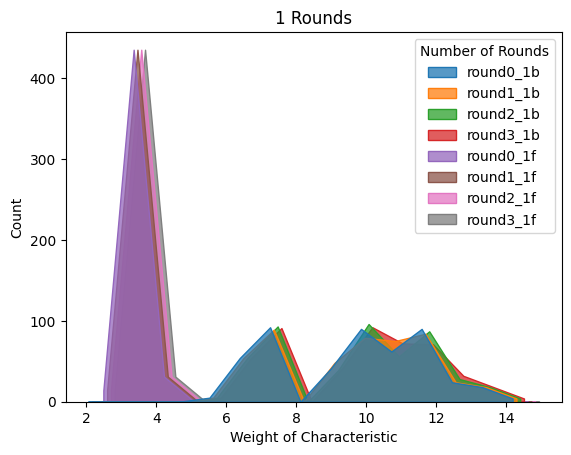

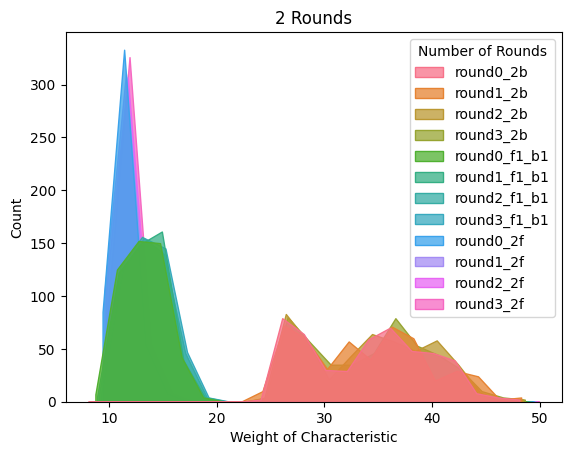

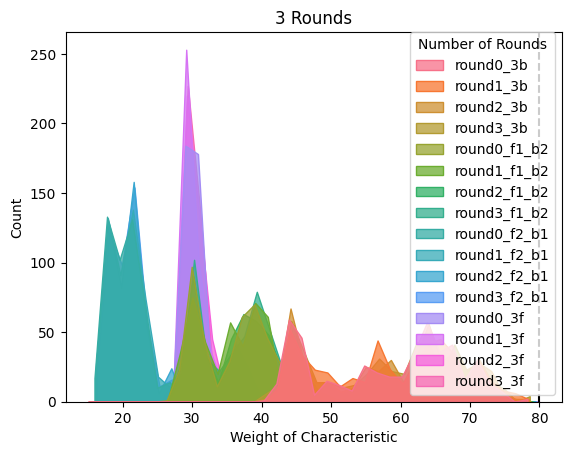

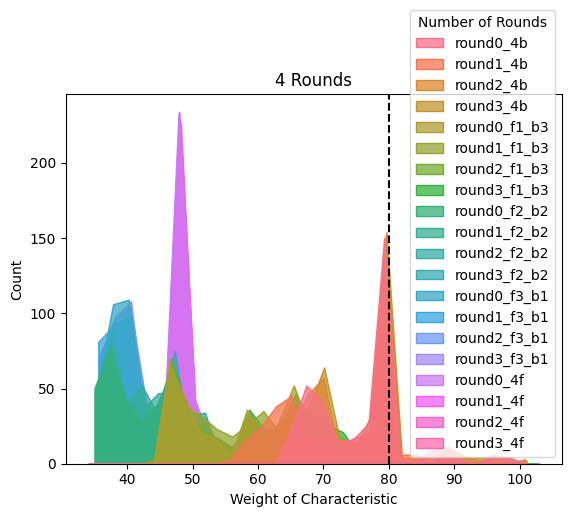

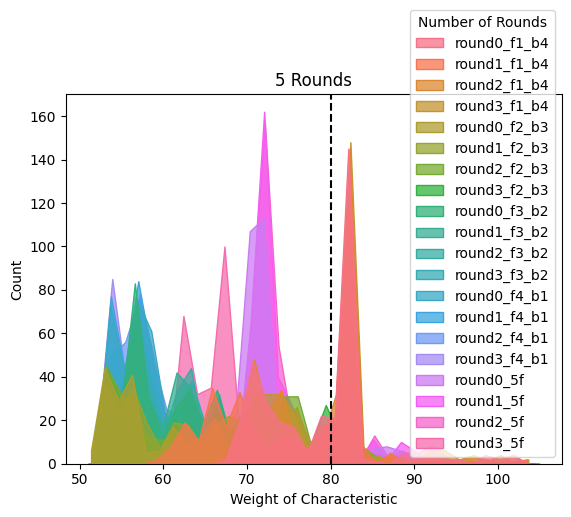

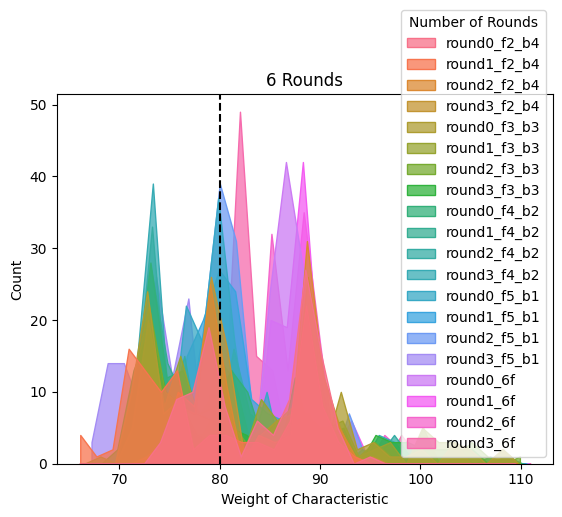

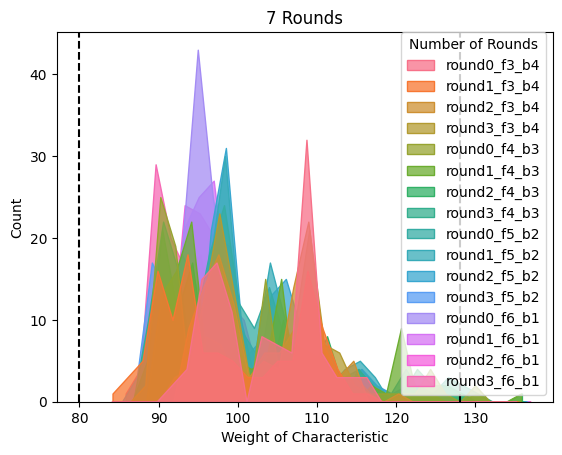

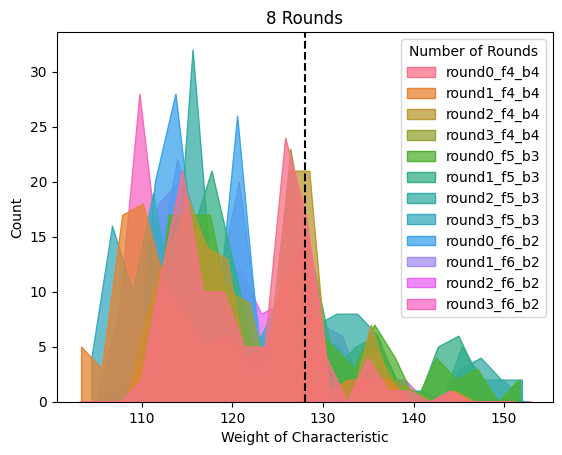

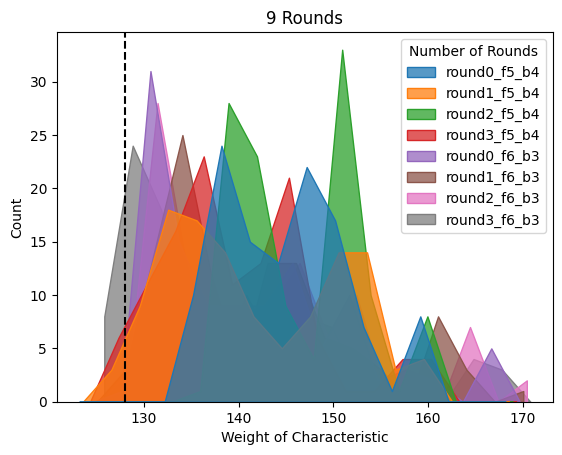

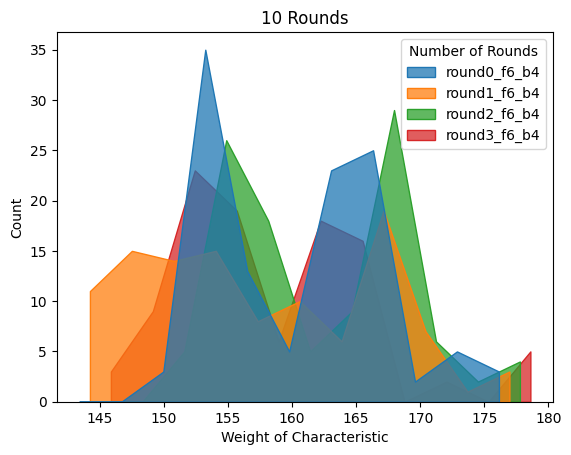

In [28]:
for rounds in range(1, max(sol_forward) + max(sol_backward) + 1):
    merged = candidates.copy()
    for (f,b) in [(a,b) for a,b in itertools.product(sol_forward,sol_backward) if a+b==rounds]:
        if f == 0:
            merged = merged.merge(backward_charact[b-1], on="input_diff", how="inner")
        elif b == 0:
            merged = merged.merge(forward_charact[f-1], on="input_diff", how="inner")
        else:
            merged = merged.merge(forward_charact[f-1], on="input_diff", how="inner")
            merged = merged.merge(backward_charact[b-1], on="input_diff", how="inner")
            for first_round in range(4):
                merged[f"round{first_round}_f{f}_b{b}"] = merged[f"round{first_round}_{f}f"] + merged[f"round{first_round}_{b}b"]
                merged = merged.drop([f"round{first_round}_{f}f", f"round{first_round}_{b}b"], axis=1)
        
    ax = sns.histplot(
        merged.melt(id_vars="input_diff", var_name='column', value_name='value').rename(columns={'column': 'Number of Rounds'}),
        x = "value",
        hue="Number of Rounds",
        multiple="dodge",
        element="poly"
    )

    x_0, x_1 = ax.get_xlim()
    if x_0-5 < 80 < x_1+5:
        ax.axvline(x=80, color='k', linestyle='--', linewidth=1.5)
    if x_0 < 128 < x_1:
        ax.axvline(x=128, color='k', linestyle='--', linewidth=1.5)

    ax.set_xlabel("Weight of Characteristic")
    ax.set_title(f"{rounds} Rounds")
    plt.show()

## Optimized for first backwards round

In [16]:
forward_charact = [
    pd.read_sql_table("probabilities", "sqlite:///2026-06-03/1_round_differentials_f.db").drop("i", axis=1).rename(columns=lambda c: c + '_1f' if c != 'input_diff' else c),
    pd.read_sql_table("probabilities", "sqlite:///2026-06-03/2_round_differentials_f.db").drop("i", axis=1).rename(columns=lambda c: c + '_2f' if c != 'input_diff' else c),
    pd.read_sql_table("probabilities", "sqlite:///2026-06-03/3_round_differentials_f.db").drop("i", axis=1).rename(columns=lambda c: c + '_3f' if c != 'input_diff' else c),
    pd.read_sql_table("probabilities", "sqlite:///2026-06-03/4_round_differentials_f.db").drop("i", axis=1).rename(columns=lambda c: c + '_4f' if c != 'input_diff' else c),
    ]

backward_charact = [
    pd.read_sql_table("probabilities", "sqlite:///2026-06-03/1_round_differentials_b.db").drop("i", axis=1).rename(columns=lambda c: c + '_1b' if c != 'input_diff' else c),
    pd.read_sql_table("probabilities", "sqlite:///2026-06-03/2_round_differentials_b.db").drop("i", axis=1).rename(columns=lambda c: c + '_2b' if c != 'input_diff' else c),
    pd.read_sql_table("probabilities", "sqlite:///2026-06-03/3_round_differentials_b.db").drop("i", axis=1).rename(columns=lambda c: c + '_3b' if c != 'input_diff' else c),
    pd.read_sql_table("probabilities", "sqlite:///2026-06-03/4_round_differentials_b.db").drop("i", axis=1).rename(columns=lambda c: c + '_4b' if c != 'input_diff' else c),
    ]

sol_forward = range(0, len(forward_charact)+1)
sol_backward = range(0, len(backward_charact)+1)
candidates = forward_charact[0].copy().drop(columns=[f"round{i}_1f" for i in range(4)])

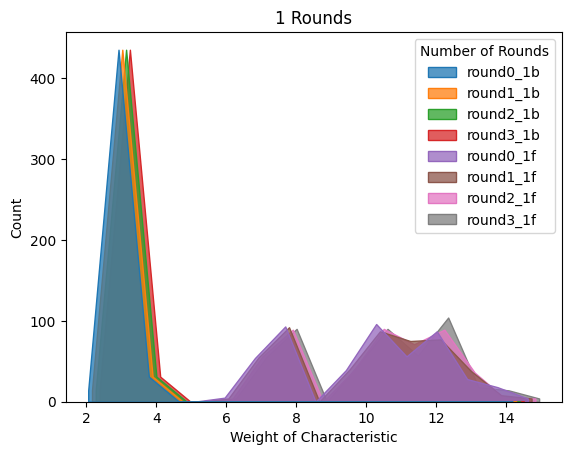

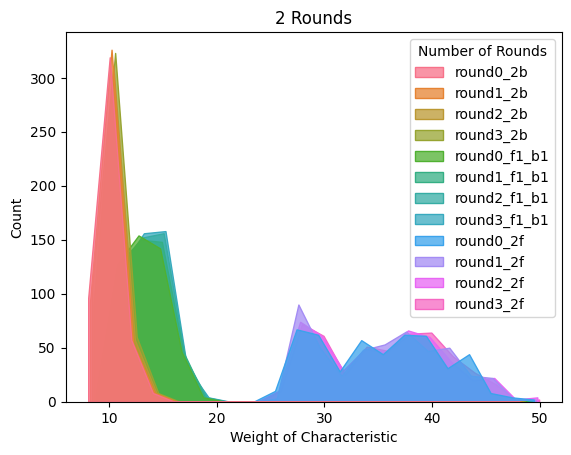

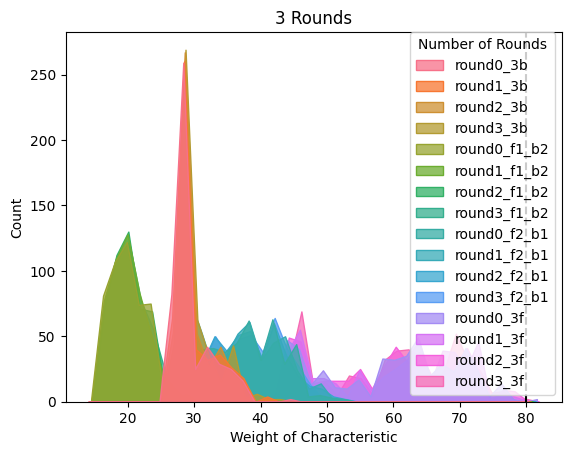

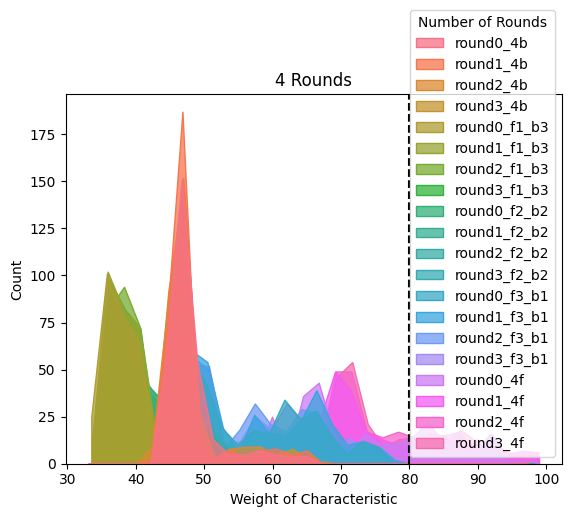

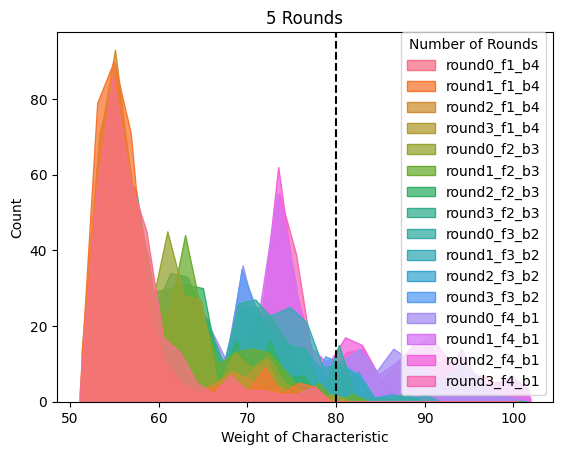

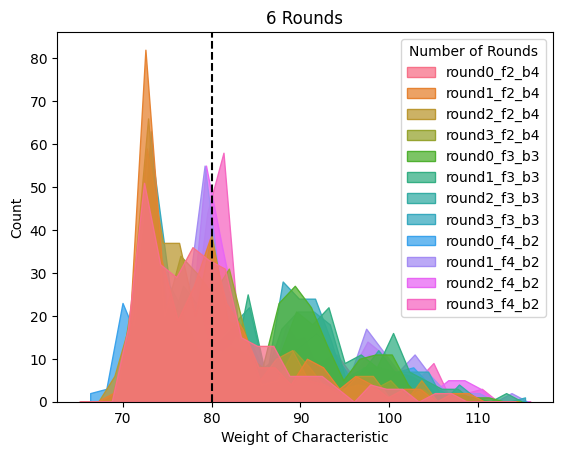

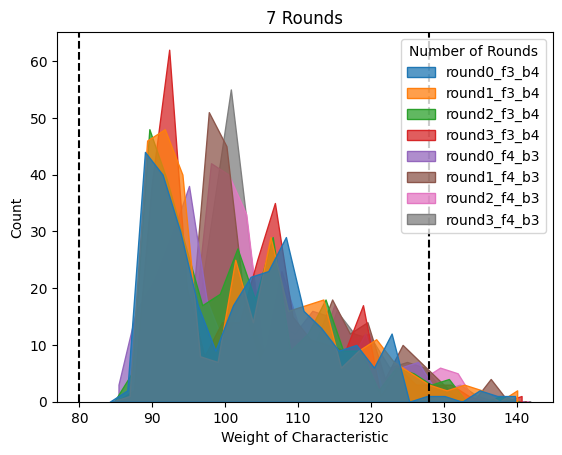

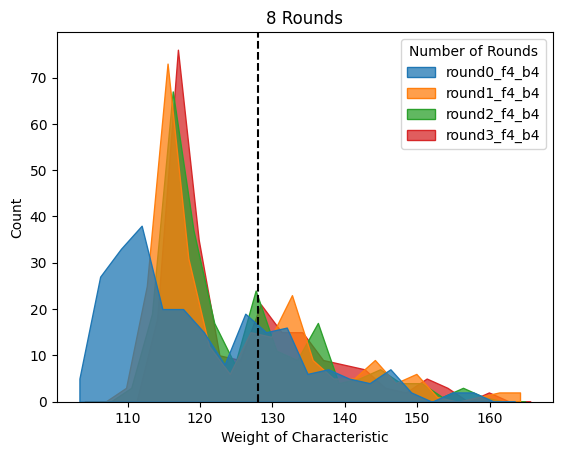

In [25]:
for rounds in range(1, max(sol_forward) + max(sol_backward) + 1):
    merged = candidates.copy()
    for (f,b) in [(a,b) for a,b in itertools.product(sol_forward,sol_backward) if a+b==rounds]:
        if f == 0:
            merged = merged.merge(backward_charact[b-1], on="input_diff", how="inner")
        elif b == 0:
            merged = merged.merge(forward_charact[f-1], on="input_diff", how="inner")
        else:
            merged = merged.merge(forward_charact[f-1], on="input_diff", how="inner")
            merged = merged.merge(backward_charact[b-1], on="input_diff", how="inner")
            for first_round in range(4):
                merged[f"round{first_round}_f{f}_b{b}"] = merged[f"round{first_round}_{f}f"] + merged[f"round{first_round}_{b}b"]
                merged = merged.drop([f"round{first_round}_{f}f", f"round{first_round}_{b}b"], axis=1)
        
    ax = sns.histplot(
        merged.melt(id_vars="input_diff", var_name='column', value_name='value').rename(columns={'column': 'Number of Rounds'}),
        x = "value",
        hue="Number of Rounds",
        multiple="dodge",
        element="poly"
    )

    x_0, x_1 = ax.get_xlim()
    if x_0-5 < 80 < x_1+5:
        ax.axvline(x=80, color='k', linestyle='--', linewidth=1.5)
    if x_0 < 128 < x_1:
        ax.axvline(x=128, color='k', linestyle='--', linewidth=1.5)
    ax.set_xlabel("Weight of Characteristic")
    ax.set_title(f"{rounds} Rounds")
    plt.show()